In [19]:
import os

def count_images(path):
    return len([
        f for f in os.listdir(path)
        if f.endswith((".jpg", ".png", ".jpeg"))
    ])

print("Dataset overview loaded from YAML:\n")
print(open("dataset.yaml").read())

train = count_images("dataset/train/images")
val = count_images("dataset/val/images")
test = count_images("dataset/test/images")

print(f"\nTrain: {train}")
print(f"Val:   {val}")
print(f"Test:  {test}")

Dataset overview loaded from YAML:

train: dataset/train/images
val: dataset/val/images
test: dataset/test/images

nc: 3

names:
  0: crack
  1: potholes
  2: wall_peeling

Train: 546
Val:   117
Test:  117


In [20]:
import os
import time
import glob
import cv2
import numpy as np
import random
import shutil
import pandas as pd
from ultralytics import YOLO

# =========================
# 🚨 FORCE OFFLINE MODE
# =========================
os.environ["ULTRALYTICS_OFFLINE"] = "1"
os.environ["YOLO_OFFLINE"] = "1"

# also prevent hub checks
os.environ["NO_PROXY"] = "*"

PROJECT_DIR = "/home/achin/COS40007-Group/jenny/runs/detect/iter_road"

In [21]:
# =========================
# BUILD DATASET SUBSET
# =========================
IMG_DIR = "dataset/train/images"
LBL_DIR = "dataset/train/labels"

ALL_IMAGES = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.endswith((".jpg", ".png", ".jpeg"))
])

random.seed(42)
random.shuffle(ALL_IMAGES)


def build_subset_folder(images, size):

    subset = images[:size]
    base = f"dataset_incremental/iter_{size}"

    img_out = f"{base}/images"
    lbl_out = f"{base}/labels"

    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    valid = 0
    missing = 0

    for img in subset:
        label = img.rsplit(".", 1)[0] + ".txt"

        img_src = f"{IMG_DIR}/{img}"
        lbl_src = f"{LBL_DIR}/{label}"

        if not os.path.exists(img_src) or not os.path.exists(lbl_src):
            missing += 1
            continue

        shutil.copy(img_src, f"{img_out}/{img}")
        shutil.copy(lbl_src, f"{lbl_out}/{label}")
        valid += 1

    yaml_path = f"{base}/data.yaml"

    with open(yaml_path, "w") as f:
        f.write(f"""
path: {base}

train: images
val: ../../dataset/val/images
test: ../../dataset/test/images

nc: 3
names:
  0: crack
  1: potholes
  2: wall_peeling
""")

    print(f"\n[iter_{size}] valid={valid}, missing={missing}")
    return yaml_path, base

In [22]:
# =========================
# IOU FUNCTION
# =========================
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    return inter / (a1 + a2 - inter + 1e-6)

# =========================
# EVALUATION FUNCTION (OFFLINE SAFE)
# =========================
def evaluate(model_path, data_yaml, run_name, split="test"):

    model = YOLO(str(model_path))   # LOCAL ONLY (NO DOWNLOAD)

    metrics = model.val(
        data=data_yaml,
        split=split,
        plots=False,
        verbose=False
    )

    image_paths = glob.glob(f"dataset/{split}/images/*")

    all_ious = []

    for img_path in image_paths:

        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]

        label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"

        gt_boxes = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    _, xc, yc, bw, bh = map(float, line.split())

                    x1 = (xc - bw/2) * w
                    y1 = (yc - bh/2) * h
                    x2 = (xc + bw/2) * w
                    y2 = (yc + bh/2) * h

                    gt_boxes.append([x1, y1, x2, y2])

        pred = model.predict(img_path, conf=0.25, verbose=False)[0]
        pred_boxes = pred.boxes.xyxy.cpu().numpy() if pred.boxes is not None else []

        for gt in gt_boxes:
            best = 0
            for pr in pred_boxes:
                best = max(best, iou(gt, pr))
            all_ious.append(best)

    return {
        "Run": run_name,
        "Split": split,
        "Precision": metrics.box.mp,
        "Recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "Mean IoU": float(np.mean(all_ious)) if all_ious else 0.0
    }


In [23]:
# =========================
# ITERATIVE TRAINING
# =========================
sizes = [400, 450, 500, 546]

val_results = []
test_results = []

# first model is local file
prev_weights = "yolo26s.pt"

for size in sizes:

    print(f"\n================ ITER {size} ================\n")

    subset_yaml, base_path = build_subset_folder(ALL_IMAGES, size)

    model = YOLO(prev_weights)   # 🚨 ALWAYS LOCAL FILE

    start = time.time()

    model.train(
        data=subset_yaml,
        epochs=300,
        patience=30,
        imgsz=640,
        batch=16,

        optimizer="AdamW",
        lr0=0.002,
        lrf=0.01,
        weight_decay=1e-4,

        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        fliplr=0.5,
        flipud=0.1,
        mosaic=1.0,
        copy_paste=0.3,
        degrees=10,
        translate=0.1,

        project=PROJECT_DIR,
        name=f"iter_{size}",
        exist_ok=True,
        device=0,
        amp=True
    )

    end = time.time()

    best_path = os.path.join(PROJECT_DIR, f"iter_{size}", "weights", "best.pt")

    print("\nEvaluating validation + test...")

    full_yaml = "dataset.yaml"

    val_summary = evaluate(best_path, full_yaml, f"iter_{size}", "val")
    test_summary = evaluate(best_path, full_yaml, f"iter_{size}", "test")

    val_summary["Time(min)"] = (end - start) / 60
    test_summary["Time(min)"] = (end - start) / 60

    val_results.append(val_summary)
    test_results.append(test_summary)

    # =========================
    # NEXT ITER MODEL UPDATE
    # =========================
    prev_weights = best_path

    print(f"Next model → {prev_weights}")



================ ITER 400 ================


[iter_400] valid=400, missing=0
Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_incremental/iter_400/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=iter_40

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 375.3±232.0 MB/s, size: 82.7 KB)
val: Scanning /home/achin/COS40007-Group/jenny/dataset/val/labels.cache... 117 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 8.8Mit/s 0.0s


/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


optimizer: AdamW(lr=0.002, momentum=0.937) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0001), 126 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/jenny/runs/detect/iter_road/iter_400/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/achin/COS40007-Group/jenny/runs/detect/iter_road/iter_400
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/300      4.66G       1.79      9.649    0.02716         16        640: 100% ━━━━━━━━━━━━ 25/25 5.8it/s 4.3s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 14.0it/s 0.3s.5s
                   all        117        165     0.0059     0.0136    0.00534    0.00117

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/300      4.98G      1.809      3.427     0.0267         16        640: 100% ━━━━━━━━━━━

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 8.4it/s 1.0s0.4ss
                   all        117        165      0.724       0.68      0.722      0.444
Speed: 0.5ms preprocess, 2.0ms inference, 0.0ms loss, 0.1ms postprocess per image
Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 491.4±250.6 MB/s, size: 32.7 KB)
val: Scanning /home/achin/COS40007-Group/jenny/dataset/test/labels.cache... 117 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 19.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 10.4it/s 0.8s.2s
                   all        117        148       0.61      0.627      0.633       0.38
Speed: 0.7ms preprocess, 2.0ms inference, 0.0ms loss, 0.1ms post

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


optimizer: AdamW(lr=0.002, momentum=0.937) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0001), 126 bias(decay=0.0)
Plotting labels to /home/achin/COS40007-Group/jenny/runs/detect/iter_road/iter_546/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/achin/COS40007-Group/jenny/runs/detect/iter_road/iter_546
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/300      4.82G      1.456      1.134    0.02165          2        640: 100% ━━━━━━━━━━━━ 35/35 5.4it/s 6.4s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 10.4it/s 0.4s.2s
                   all        117        165      0.701       0.54      0.552      0.272

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/300      5.14G       1.37       1.14      0.019          2        640: 100% ━━━━━━━━━━━

/home/achin/COS40007-Group/.venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 9.1it/s 0.9s0.2s
                   all        117        165      0.811      0.688      0.749      0.477
Speed: 0.5ms preprocess, 1.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Ultralytics 8.4.56 🚀 Python-3.9.25 torch-2.8.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 494.5±386.4 MB/s, size: 41.7 KB)
val: Scanning /home/achin/COS40007-Group/jenny/dataset/test/labels.cache... 117 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 117/117 21.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 9.4it/s 0.9s<0.1s
                   all        117        148      0.751      0.655      0.729      0.443
Speed: 0.6ms preprocess, 1.8ms inference, 0.0ms loss, 0.5ms post

In [24]:
# =========================
# FINAL RESULTS
# =========================
val_df = pd.DataFrame(val_results)
test_df = pd.DataFrame(test_results)

print("\n=== VALIDATION RESULTS ===")
print(val_df)

print("\n=== TEST RESULTS ===")
print(test_df)


=== VALIDATION RESULTS ===
        Run Split  Precision    Recall     mAP50  mAP50-95  Mean IoU  \
0  iter_400   val   0.650237  0.619788  0.655724  0.374054  0.458863   
1  iter_450   val   0.682188  0.689141  0.717065  0.439719  0.569041   
2  iter_500   val   0.724158  0.680475  0.721909  0.443927  0.553710   
3  iter_546   val   0.810676  0.687773  0.749090  0.476939  0.557317   

   Time(min)  
0   8.177574  
1   9.114787  
2   9.201291  
3  10.138050  

=== TEST RESULTS ===
        Run Split  Precision    Recall     mAP50  mAP50-95  Mean IoU  \
0  iter_400  test   0.564167  0.590859  0.622219  0.329864  0.456415   
1  iter_450  test   0.752995  0.599786  0.680936  0.386224  0.554953   
2  iter_500  test   0.609653  0.626745  0.632923  0.379504  0.533822   
3  iter_546  test   0.751005  0.655095  0.728757  0.443298  0.553430   

   Time(min)  
0   8.177574  
1   9.114787  
2   9.201291  
3  10.138050  


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

def plot_curves(iter_size):

    csv_path = f"{PROJECT_DIR}/iter_{iter_size}/results.csv"

    if not os.path.exists(csv_path):
        print(f"results.csv not found for iter_{iter_size}")
        return

    df = pd.read_csv(csv_path)

    plt.figure(figsize=(14,5))

    # ======================
    # LOSS CURVES
    # ======================
    plt.subplot(1,2,1)

    loss_cols = [
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss"
    ]

    for col in loss_cols:
        if col in df.columns:
            plt.plot(df["epoch"], df[col], label=col)

    plt.title(f"Iter {iter_size} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # ======================
    # METRICS CURVES
    # ======================
    plt.subplot(1,2,2)

    metric_cols = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]

    for col in metric_cols:
        if col in df.columns:
            plt.plot(df["epoch"], df[col], label=col)

    plt.title(f"Iter {iter_size} Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"{PROJECT_DIR}/iter_{iter_size}/training_curves.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

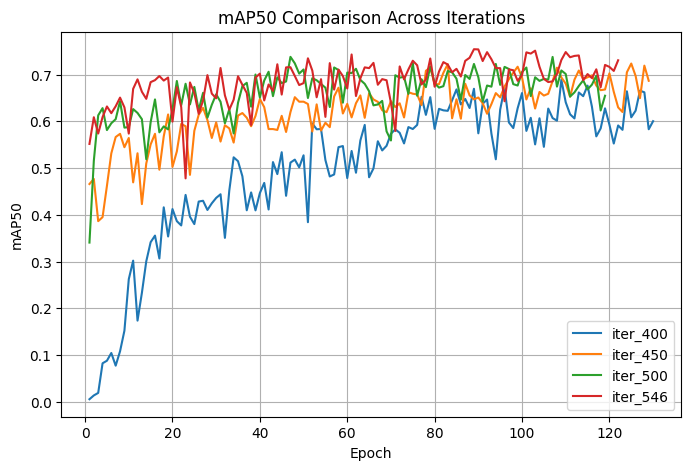

In [26]:
def compare_map50():

    plt.figure(figsize=(8,5))

    for size in sizes:

        csv_path = f"{PROJECT_DIR}/iter_{size}/results.csv"
        df = pd.read_csv(csv_path)

        plt.plot(
            df["epoch"],
            df["metrics/mAP50(B)"],
            label=f"iter_{size}"
        )

    plt.xlabel("Epoch")
    plt.ylabel("mAP50")
    plt.title("mAP50 Comparison Across Iterations")
    plt.legend()
    plt.grid(True)
    plt.show()

compare_map50()

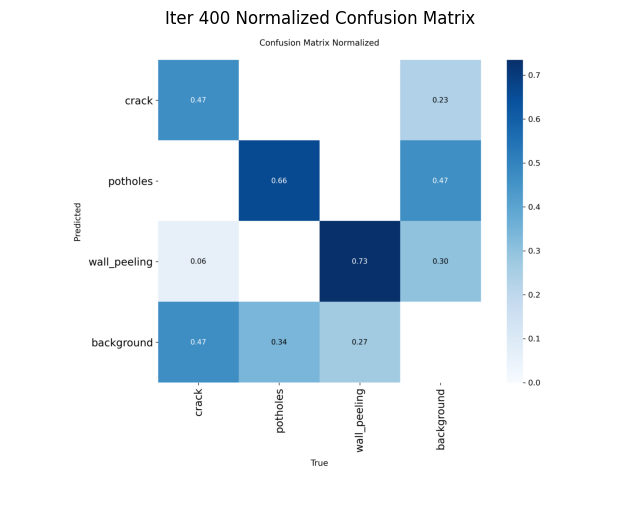

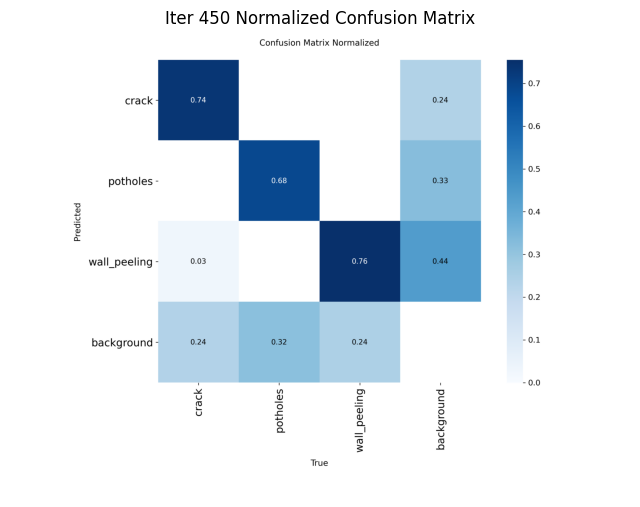

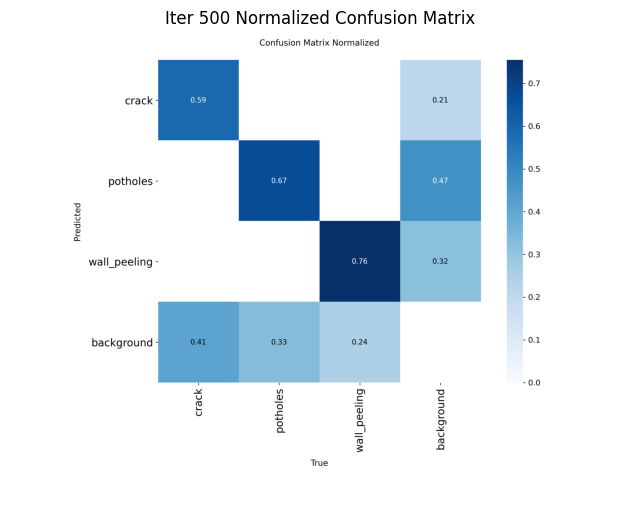

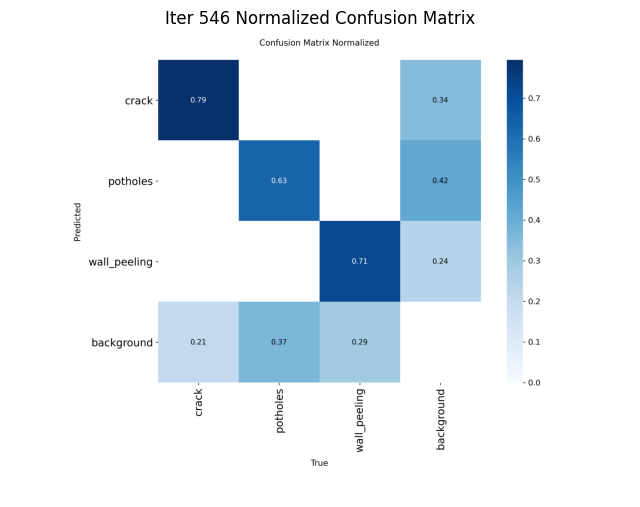

In [27]:
from PIL import Image
import matplotlib.pyplot as plt
import os

for size in [400, 450, 500, 546]:

    img_path = os.path.join(
        PROJECT_DIR,
        f"iter_{size}",
        "confusion_matrix_normalized.png"
    )

    if not os.path.exists(img_path):
        print(f"Normalized confusion matrix not found for iter_{size}")
        continue

    img = Image.open(img_path)

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Iter {size} Normalized Confusion Matrix")
    plt.show()

In [28]:
from ultralytics import YOLO
import glob
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(model_path, split="test", max_images=5):

    model = YOLO(model_path)

    image_paths = sorted(
        glob.glob(f"dataset/{split}/images/*")
    )[:max_images]

    for img_path in image_paths:

        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w = img.shape[:2]

        # ======================
        # PREDICTIONS
        # ======================
        pred = model.predict(img_path, conf=0.25, verbose=False)[0]

        pred_boxes = pred.boxes.xyxy.cpu().numpy() if pred.boxes is not None else []
        pred_conf = pred.boxes.conf.cpu().numpy() if pred.boxes is not None else []

        # ======================
        # GROUND TRUTH
        # ======================
        label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"

        gt_boxes = []

        if os.path.exists(label_path):

            with open(label_path) as f:

                for line in f:

                    _, xc, yc, bw, bh = map(float, line.split())

                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    x2 = (xc + bw / 2) * w
                    y2 = (yc + bh / 2) * h

                    gt_boxes.append([x1, y1, x2, y2])

        # ======================
        # DRAW PREDICTIONS (RED)
        # ======================
        for i, box in enumerate(pred_boxes):

            x1, y1, x2, y2 = map(int, box)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

            conf = pred_conf[i]

            cv2.putText(img, f"Conf={conf:.2f}", (x1, max(20, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        # ======================
        # DRAW GT (GREEN) + IoU
        # ======================
        for gt in gt_boxes:

            x1, y1, x2, y2 = map(int, gt)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            best_iou = 0

            for pred_box in pred_boxes:
                best_iou = max(best_iou, iou(gt, pred_box))

            cv2.putText(img, f"IoU={best_iou:.2f}", (x1, y2 + 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

        # ======================
        # LEGEND
        # ======================
        cv2.putText(img, "Green = Ground Truth | Red = Prediction",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        # ======================
        # DISPLAY
        # ======================
        plt.figure(figsize=(8, 8))

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        plt.title(os.path.basename(img_path))

        plt.axis("off")
        plt.show()

In [29]:
show_predictions(
    model_path="runs/detect/iter_road/iter_400/weights/best.pt",
    iter_size=400,
    split="test",
    max_images=5
)

TypeError: show_predictions() got an unexpected keyword argument 'iter_size'

In [ ]:
show_predictions(
    model_path="runs/detect/iter_road/iter_450/weights/best.pt",
    iter_size=450,
    split="test",
    max_images=5
)

In [ ]:
show_predictions(
    model_path="runs/detect/iter_road/iter_500/weights/best.pt",
    iter_size=500,
    split="test",
    max_images=5
)

In [ ]:
show_predictions(
    model_path="runs/detect/iter_road/iter_546/weights/best.pt",
    iter_size=546,
    split="test",
    max_images=5
)